In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
df = pd.read_csv("public/data.csv")

In [53]:
df.head()

,label_id,tenant_id,survey_participation_id,participant_id,survey_id,question_id,evaluated_at,score,sentiment,risk_flag,...,confidence,themes,risk_flags,action,label_payload,label_version,prompt_version,label_model,input_fingerprint,labeled_at
0,3,1,7,1,1768646102913,12,2026-01-17 10:39:03.848789+00,0.20,negative,f,...,0.90,"[""process""]",[],watch,"{""action"": ""watch"", ""themes"": [""process""], ""se...",v1,labeler_v1_2026_01_19,gpt-4.1-mini,a397d2911852c6a9b95c87551450e1dde751dc53f08c51...,2026-01-19 21:02:58.057762+00
1,4,1,8,1,1768646102913,13,2026-01-17 10:39:05.41022+00,0.95,positive,f,...,0.95,[],[],ignore,"{""action"": ""ignore"", ""themes"": [], ""severity"":...",v1,labeler_v1_2026_01_19,gpt-4.1-mini,beae5bb38347d18b207f99c0456eac725fcbddb81c99b9...,2026-01-19 21:02:58.057762+00
2,5,1,9,1,1768646102913,14,2026-01-17 10:39:06.740269+00,0.20,negative,f,...,0.80,"[""tools_systems""]",[],watch,"{""action"": ""watch"", ""themes"": [""tools_systems""...",v1,labeler_v1_2026_01_19,gpt-4.1-mini,bf6fdc83fb6d90e78334ff212f6ee7b4568b2359bec6c3...,2026-01-19 21:02:58.057762+00
3,6,1,10,1,1768646102913,15,2026-01-17 10:39:08.410775+00,0.20,negative,f,...,0.90,"[""process""]",[],watch,"{""action"": ""watch"", ""themes"": [""process""], ""se...",v1,labeler_v1_2026_01_19,gpt-4.1-mini,1b63c1c2985103dc4f73d81a2d9a64a13cdd842604f9cb...,2026-01-19 21:02:58.057762+00
4,7,1,11,11,1768646102913,12,2026-01-17 10:40:04.343153+00,0.90,positive,f,...,0.90,[],[],ignore,"{""action"": ""ignore"", ""themes"": [], ""severity"":...",v1,labeler_v1_2026_01_19,gpt-4.1-mini,87aec123ecf21aa518125324b89e187aa9a253d508c01b...,2026-01-19 21:02:58.057762+00


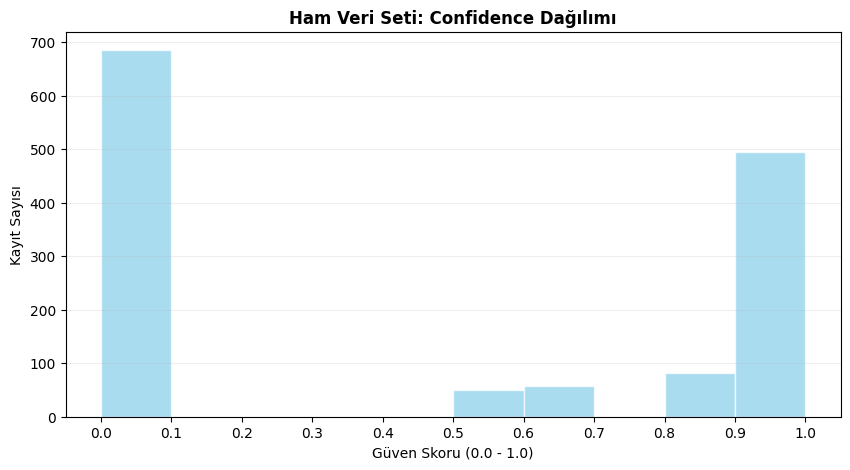

In [59]:
plt.figure(figsize=(10, 5))


plt.hist(df['confidence'], bins=10, range=(0, 1), color='skyblue', edgecolor='white', alpha=0.7)
plt.xticks(np.arange(0, 1.1, 0.1))
plt.title('Ham Veri Seti: Confidence Dağılımı', fontsize=12, fontweight='bold')
plt.xlabel('Güven Skoru (0.0 - 1.0)')
plt.ylabel('Kayıt Sayısı')
plt.grid(axis='y', alpha=0.2)
plt.show()

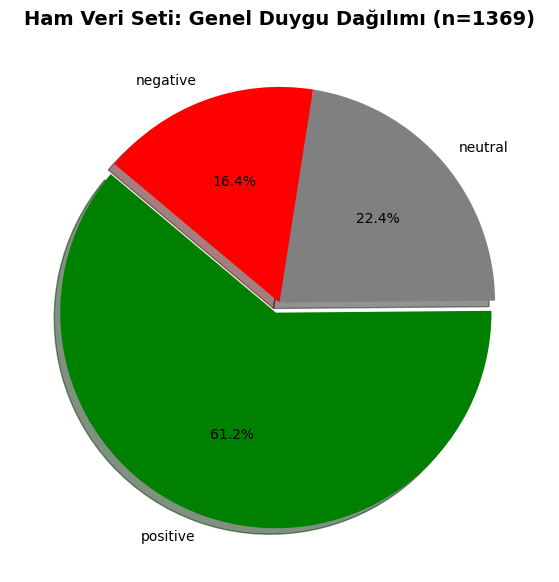

In [55]:
raw_sentiment_counts = df['sentiment'].value_counts()

plt.figure(figsize=(10, 7))
colors = ['green', 'gray', 'red']
plt.pie(raw_sentiment_counts, labels=raw_sentiment_counts.index, autopct='%1.1f%%',
        startangle=140, colors=colors, explode=explode, shadow=True)
plt.title('Ham Veri Seti: Genel Duygu Dağılımı (n=1369)', fontsize=14, fontweight='bold')
plt.show()

In [56]:
df_clean = df[df['should_display'] == "t"].copy()

print(f"🧹 Temizlik sonrası aktif kayıt sayısı: {len(df_clean)}")
print(f"📊 Elenen gürültü (noise) veri sayısı: {len(df) - len(df_clean)}")

zero_conf_display = df[(df['confidence'] == 0) & (df['should_display'] == True)]
print(f"⚠️ Confidence 0 olup Display=True olan hatalı kayıt sayısı: {len(zero_conf_display)}")

🧹 Temizlik sonrası aktif kayıt sayısı: 232
📊 Elenen gürültü (noise) veri sayısı: 1137
⚠️ Confidence 0 olup Display=True olan hatalı kayıt sayısı: 0


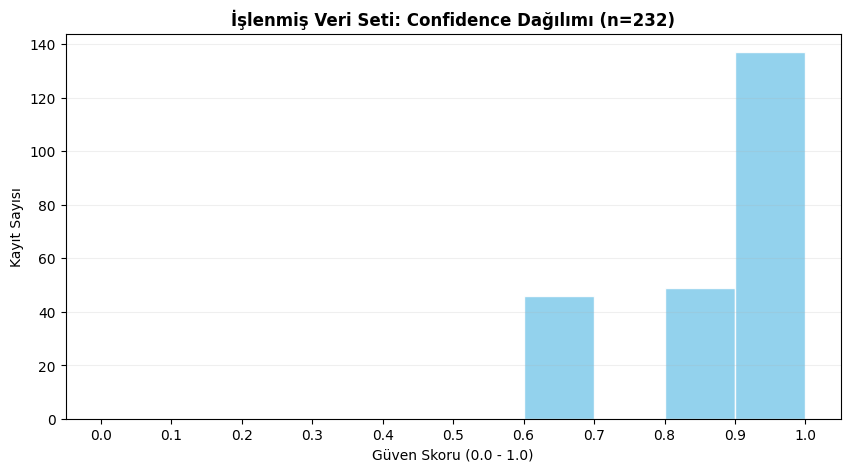

In [58]:
plt.figure(figsize=(10, 5))


plt.hist(df_clean['confidence'], bins=10, range=(0, 1), color='skyblue', edgecolor='white', alpha=0.9)
plt.xticks(np.arange(0, 1.1, 0.1))
plt.title('İşlenmiş Veri Seti: Confidence Dağılımı (n=232)', fontsize=12, fontweight='bold')
plt.xlabel('Güven Skoru (0.0 - 1.0)')
plt.ylabel('Kayıt Sayısı')
plt.grid(axis='y', alpha=0.2)

plt.show()

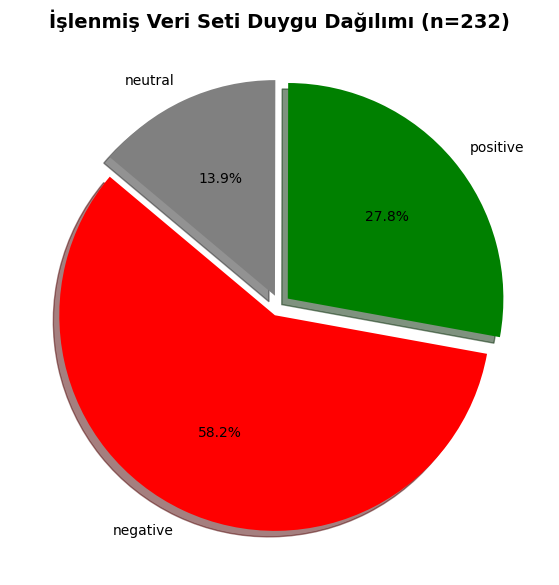

In [60]:
plt.figure(figsize=(10, 7))
sentiment_counts = df_clean['sentiment'].value_counts()
colors = ['red', 'green', 'gray']
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%',
        startangle=140, colors=colors, explode=(0.05, 0.05, 0.05), shadow=True)
plt.title('İşlenmiş Veri Seti Duygu Dağılımı (n=232)', fontsize=14, fontweight='bold')
plt.show()